# Difference-in-Differences: Minimum Wage Project

This notebook analyzes the minimum wage case using the Difference-in-Differences methodology.

## 1.0 Project Problem Statement

Minimum wage policy remains one of the most debated labor-market interventions in economics and public policy. Classical labor demand theory suggests that increasing the minimum wage may raise labor costs and potentially reduce employment, especially among low-wage workers and labor-intensive businesses. However, empirical evidence has shown that the actual employment effect may vary depending on market structure, firm behavior, worker turnover, local economic conditions, and adjustment mechanisms used by employers.

This project examines the impact of the April 1992 New Jersey minimum wage increase on employment levels in the fast-food sector. New Jersey restaurants are treated as the policy-affected group, while Pennsylvania restaurants serve as the comparison group because they were not directly exposed to the same minimum wage increase during the study period.

The central policy question is:

**Did the April 1992 minimum wage increase in New Jersey reduce employment relative to Pennsylvania, or did employment remain stable after the policy change?**

To answer this question, the project applies the Difference-in-Differences method, which compares employment changes over time between the treated group and the comparison group.

## 2.0 Project Objective

The main objective of this project is to estimate the causal impact of the April 1992 New Jersey minimum wage increase on employment levels in fast-food restaurants using the Difference-in-Differences method.

Specifically, the project aims to:

1. Compare employment levels in New Jersey and Pennsylvania before and after the April 1992 minimum wage increase.
2. Estimate the treatment effect of the minimum wage increase using the interaction between treatment status and post-policy period.
3. Assess whether employment in New Jersey declined, increased, or remained stable relative to Pennsylvania after the policy intervention.
4. Improve the interpretation of model results by estimating different OLS specifications with and without control variables.
5. Visualize the Difference-in-Differences logic using observed and counterfactual employment trends.
6. Provide policy interpretation on whether the minimum wage increase was associated with employment losses.

The key parameter of interest is the coefficient on the interaction term:

**New Jersey × After April 1992**

This coefficient represents the Difference-in-Differences estimate of the policy impact.

## 3.0 Methodology

This project uses the Difference-in-Differences econometric framework to estimate the effect of the New Jersey minimum wage increase on employment.

The Difference-in-Differences approach compares two groups across two time periods:

| Group | Before April 1992 | After April 1992 |
|---|---:|---:|
| Treatment group | New Jersey restaurants before the minimum wage increase | New Jersey restaurants after the minimum wage increase |
| Comparison group | Pennsylvania restaurants before the same date | Pennsylvania restaurants after the same date |

Pennsylvania serves as the comparison group because it was not directly affected by the New Jersey minimum wage policy change. The method estimates whether the employment change in New Jersey differed from the employment change in Pennsylvania after the policy was implemented.

The baseline Difference-in-Differences model is specified as:

\[
FTE_{it} = \beta_0 + \beta_1 NJ_i + \beta_2 POST_t + \beta_3 (NJ_i \times POST_t) + \epsilon_{it}
\]

Where:

| Term | Meaning |
|---|---|
| \(FTE_{it}\) | Full-time equivalent employment for restaurant \(i\) at time \(t\) |
| \(NJ_i\) | Treatment indicator equal to 1 for New Jersey restaurants and 0 for Pennsylvania restaurants |
| \(POST_t\) | Time indicator equal to 1 after April 1992 and 0 before April 1992 |
| \(NJ_i \times POST_t\) | Treatment interaction term capturing the Difference-in-Differences effect |
| \(\beta_0\) | Baseline employment level for Pennsylvania before April 1992 |
| \(\beta_1\) | Baseline employment difference between New Jersey and Pennsylvania before the policy |
| \(\beta_2\) | General post-period employment change in Pennsylvania |
| \(\beta_3\) | Estimated causal effect of the New Jersey minimum wage increase |
| \(\epsilon_{it}\) | Error term |

The coefficient \(\beta_3\) is the key estimate. If \(\beta_3\) is negative and statistically significant, it would suggest that the minimum wage increase reduced employment in New Jersey relative to Pennsylvania. If \(\beta_3\) is zero or positive, it would suggest that the policy did not reduce employment.

## 4.0 Analytical Approach

The analysis follows a structured econometric workflow.

First, the dataset is prepared by defining employment as the outcome variable and constructing the key Difference-in-Differences indicators: `NJ`, `POST_APRIL92`, and `NJ_POST_APRIL92`.

Second, a baseline OLS Difference-in-Differences model is estimated using only the treatment indicator, post-period indicator, and interaction term. This model provides the cleanest estimate of the average policy effect.

Third, additional model specifications are estimated by adding control variables such as restaurant chain type, ownership type, and geographic indicators. These controls help account for observable differences across restaurants that may influence employment levels independently of the minimum wage policy.

Fourth, model coefficients are interpreted with particular attention to the interaction term. The interaction term represents the estimated employment change in New Jersey after the minimum wage increase relative to the employment change observed in Pennsylvania.

Finally, the results are visualized using a Difference-in-Differences chart showing three lines:

1. Observed employment trend in Pennsylvania.
2. Observed employment trend in New Jersey.
3. Counterfactual New Jersey trend showing what New Jersey employment would have looked like if it had followed the Pennsylvania post-period change.

This visual approach helps translate the regression results into a policy-relevant interpretation.

## 5.0 Key Variables Used in the Difference-in-Differences Model

The core variables used in the analysis are summarized below.

| Variable | Description | Role in the Model |
|---|---|---|
| `fte` | Full-time equivalent employment | Dependent variable |
| `NJ` | Indicator equal to 1 for New Jersey restaurants and 0 for Pennsylvania restaurants | Treatment group indicator |
| `POST_APRIL92` | Indicator equal to 1 after April 1992 and 0 before April 1992 | Post-policy period indicator | a
| `NJ_POST_APRIL92` | Interaction between `NJ` and `POST_APRIL92` | Difference-in-Differences treatment effect |
| `bk`, `kfc`, `wendys`, `roys` | Restaurant chain indicators | Chain-level controls |
| `co_owned` | Ownership structure indicator | Ownership control |
| `southj`, `centralj`, `pa1`, `pa2` | Regional indicators | Geographic controls |

The most important variable is `NJ_POST_APRIL92`. This variable identifies restaurants that were both located in New Jersey and observed after the April 1992 minimum wage increase. Its coefficient measures the estimated treatment effect of the policy.

In [2]:
# Load dataset
import pandas as pd 
import numpy as np 

data = pd.read_csv('./data/njmin3.csv')
data.head()

,NJ,POST_APRIL92,NJ_POST_APRIL92,fte,bk,kfc,roys,wendys,co_owned,centralj,southj,pa1,pa2,demp
0,1,0,0,15.00,1,0,0,0,0,1,0,0,0,12.00
1,1,0,0,15.00,1,0,0,0,0,1,0,0,0,6.50
2,1,0,0,24.00,0,0,1,0,0,1,0,0,0,-1.00
3,1,0,0,19.25,0,0,1,0,1,0,0,0,0,2.25
4,1,0,0,21.50,1,0,0,0,0,0,0,0,0,13.00


In [3]:
# Data types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NJ               820 non-null    int64  
 1   POST_APRIL92     820 non-null    int64  
 2   NJ_POST_APRIL92  820 non-null    int64  
 3   fte              794 non-null    float64
 4   bk               820 non-null    int64  
 5   kfc              820 non-null    int64  
 6   roys             820 non-null    int64  
 7   wendys           820 non-null    int64  
 8   co_owned         820 non-null    int64  
 9   centralj         820 non-null    int64  
 10  southj           820 non-null    int64  
 11  pa1              820 non-null    int64  
 12  pa2              820 non-null    int64  
 13  demp             768 non-null    float64
dtypes: float64(2), int64(12)
memory usage: 89.8 KB


In [4]:
# Missing values
data.isna().sum()

NJ                  0
POST_APRIL92        0
NJ_POST_APRIL92     0
fte                26
bk                  0
kfc                 0
roys                0
wendys              0
co_owned            0
centralj            0
southj              0
pa1                 0
pa2                 0
demp               52
dtype: int64

In [5]:
# Variables correlation
data.corr(numeric_only=True)

,NJ,POST_APRIL92,NJ_POST_APRIL92,fte,bk,kfc,roys,wendys,co_owned,centralj,southj,pa1,pa2,demp
NJ,1.000000e+00,-1.408262e-16,0.401938,-0.063649,-2.572595e-02,5.328421e-02,2.999192e-02,-6.017026e-02,-1.082782e-02,2.081637e-01,2.646131e-01,-6.350617e-01,-7.006508e-01,1.209927e-01
POST_APRIL92,-1.408262e-16,1.000000e+00,0.822734,0.002943,6.882597e-17,2.088890e-16,-1.095800e-16,-7.438666e-17,1.333580e-16,5.987910e-17,2.093973e-17,6.082260e-17,1.284285e-16,-1.234829e-17
NJ_POST_APRIL92,4.019380e-01,8.227342e-01,1.000000,0.000080,-1.034024e-02,2.141695e-02,1.205489e-02,-2.418472e-02,-4.352114e-03,8.366893e-02,1.063581e-01,-2.552554e-01,-2.816182e-01,4.890839e-02
fte,-6.364875e-02,2.942791e-03,0.000080,1.000000,2.574871e-01,-4.239253e-01,3.597686e-02,7.849146e-02,-1.327564e-01,3.453084e-02,-2.265743e-01,6.162658e-02,2.501320e-02,-7.647718e-02
bk,-2.572595e-02,6.882597e-17,-0.010340,0.257487,1.000000e+00,-4.164733e-01,-4.772396e-01,-3.502198e-01,-3.520561e-01,-4.493078e-02,-8.017613e-02,5.217919e-02,-1.508115e-02,4.702877e-02
kfc,5.328421e-02,2.088890e-16,0.021417,-0.423925,-4.164733e-01,1.000000e+00,-2.777956e-01,-2.038589e-01,1.099744e-01,1.207149e-02,1.448132e-01,-2.227718e-02,-4.801278e-02,5.706485e-02
roys,2.999192e-02,-1.095800e-16,0.012055,0.035977,-4.772396e-01,-2.777956e-01,1.000000e+00,-2.336033e-01,4.073680e-01,4.405685e-02,-6.206871e-03,-1.549091e-01,1.044790e-01,-1.148608e-01
wendys,-6.017026e-02,-7.438666e-17,-0.024185,0.078491,-3.502198e-01,-2.038589e-01,-2.336033e-01,1.000000e+00,-1.254319e-01,-4.200470e-03,-4.300342e-02,1.397562e-01,-5.163580e-02,9.217689e-03
co_owned,-1.082782e-02,1.333580e-16,-0.004352,-0.132756,-3.520561e-01,1.099744e-01,4.073680e-01,-1.254319e-01,1.000000e+00,-1.233884e-01,1.228197e-01,-7.947556e-02,8.734772e-02,-2.732267e-02
centralj,2.081637e-01,5.987910e-17,0.083669,0.034531,-4.493078e-02,1.207149e-02,4.405685e-02,-4.200470e-03,-1.233884e-01,1.000000e+00,-2.307902e-01,-1.321968e-01,-1.458501e-01,-2.555614e-02


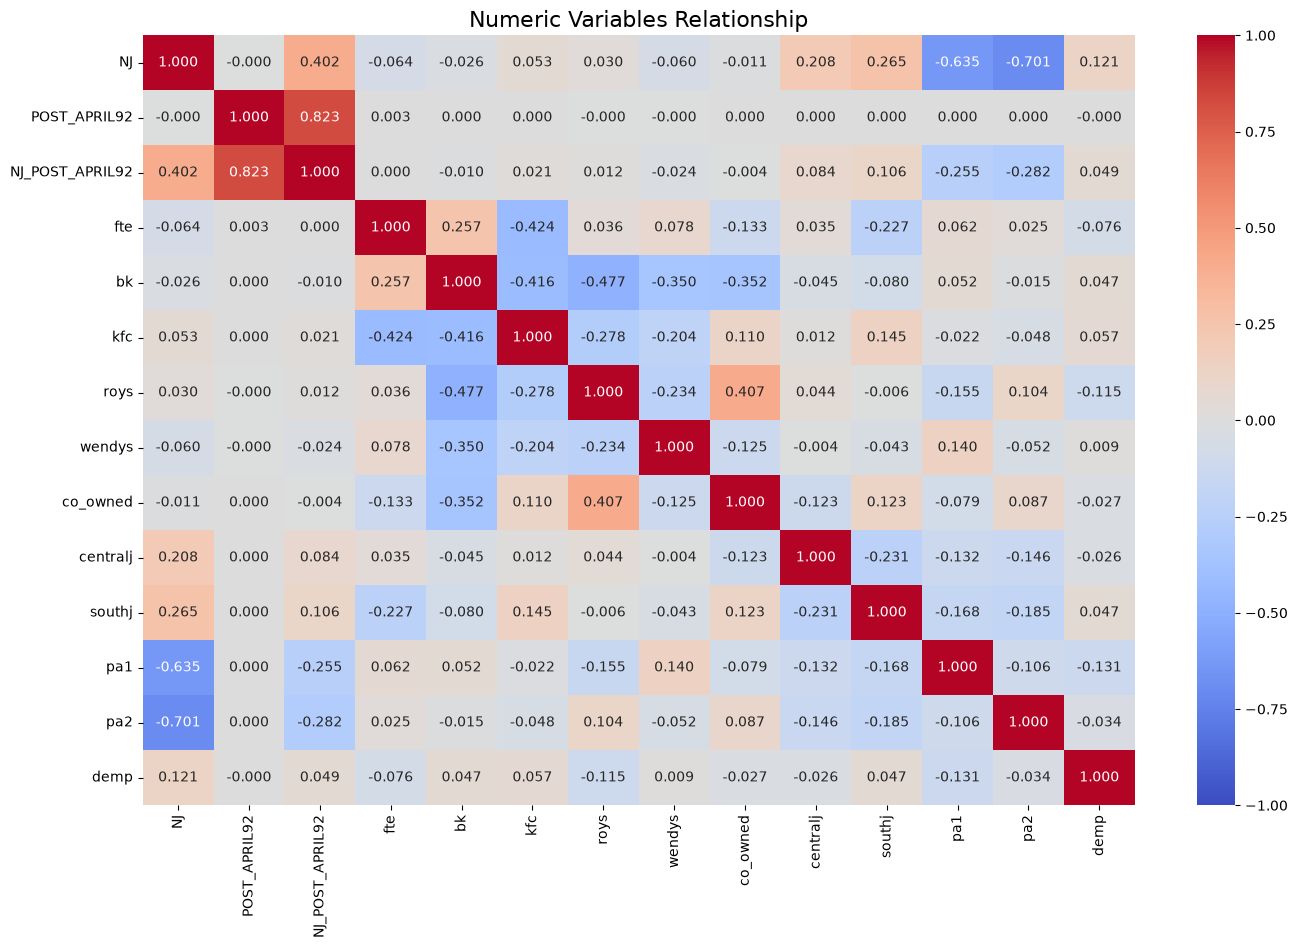

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize Variables correlation
plt.figure(figsize=(16, 10))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm', annot=True, vmin=-1, vmax=1, fmt='.3f')
plt.title("Numeric Variables Relationship", fontsize=16)
plt.show()

In [7]:
# Get the summary statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
NJ,820.0,0.807317,0.394647,0.0,1.0,1.0,1.0,1.0
POST_APRIL92,820.0,0.500000,0.500305,0.0,0.0,0.5,1.0,1.0
NJ_POST_APRIL92,820.0,0.403659,0.490930,0.0,0.0,0.0,1.0,1.0
fte,794.0,21.026511,9.422746,0.0,14.5,20.0,25.5,85.0
bk,820.0,0.417073,0.493376,0.0,0.0,0.0,1.0,1.0
kfc,820.0,0.195122,0.396536,0.0,0.0,0.0,0.0,1.0
roys,820.0,0.241463,0.428232,0.0,0.0,0.0,0.0,1.0
wendys,820.0,0.146341,0.353664,0.0,0.0,0.0,0.0,1.0
co_owned,820.0,0.343902,0.475299,0.0,0.0,0.0,1.0,1.0
centralj,820.0,0.153659,0.360841,0.0,0.0,0.0,0.0,1.0


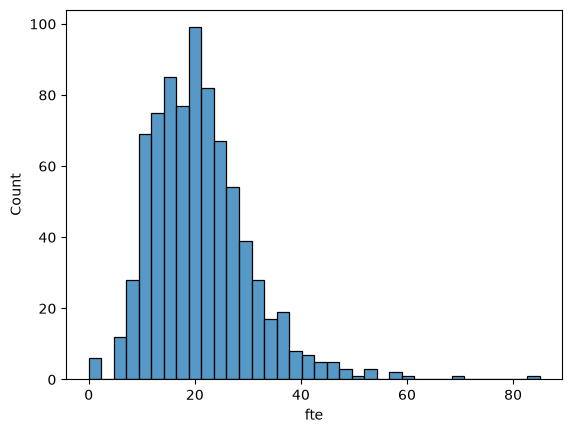

In [8]:
import seaborn as sns 

# plot the histogram of the data
sns.histplot(data=data, x='fte');

/Users/emmanueldanielchonza/Documents/Documents - Emmanuel’s MacBook Pro/Education/Projects/Econometrics-and-Research-Techniques/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


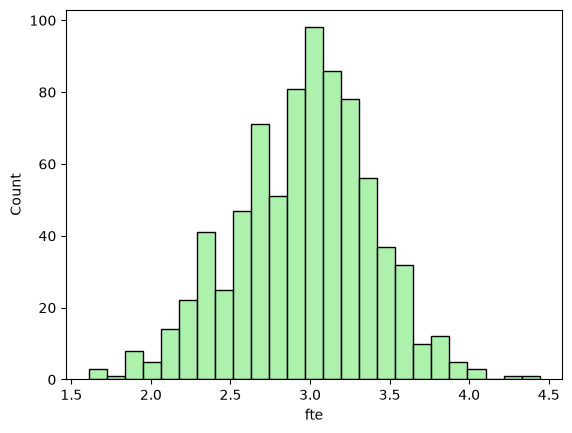

In [9]:
import seaborn as sns 

# Plot the log of the FTE
sns.histplot(data=data, x=np.log(data['fte']), color='lightgreen');

In [10]:
# Impute missing values in selected numeric columns using mean strategy

from sklearn.impute import SimpleImputer

# Columns to impute
cols_to_impute = ["fte", "demp"]

# Check missing values before imputation
print("Missing values before imputation:")
print(data[cols_to_impute].isna().sum())

Missing values before imputation:
fte     26
demp    52
dtype: int64


In [11]:
# Initialize mean imputer
mean_imputer = SimpleImputer(strategy="mean")

# Fit the imputer and transform only the selected columns
data[cols_to_impute] = mean_imputer.fit_transform(data[cols_to_impute])

# Check missing values after imputation
print("\nMissing values after imputation:")
print(data[cols_to_impute].isna().sum())


Missing values after imputation:
fte     0
demp    0
dtype: int64


In [12]:
# Check for missing values across columns
data.isna().sum()

NJ                 0
POST_APRIL92       0
NJ_POST_APRIL92    0
fte                0
bk                 0
kfc                0
roys               0
wendys             0
co_owned           0
centralj           0
southj             0
pa1                0
pa2                0
demp               0
dtype: int64

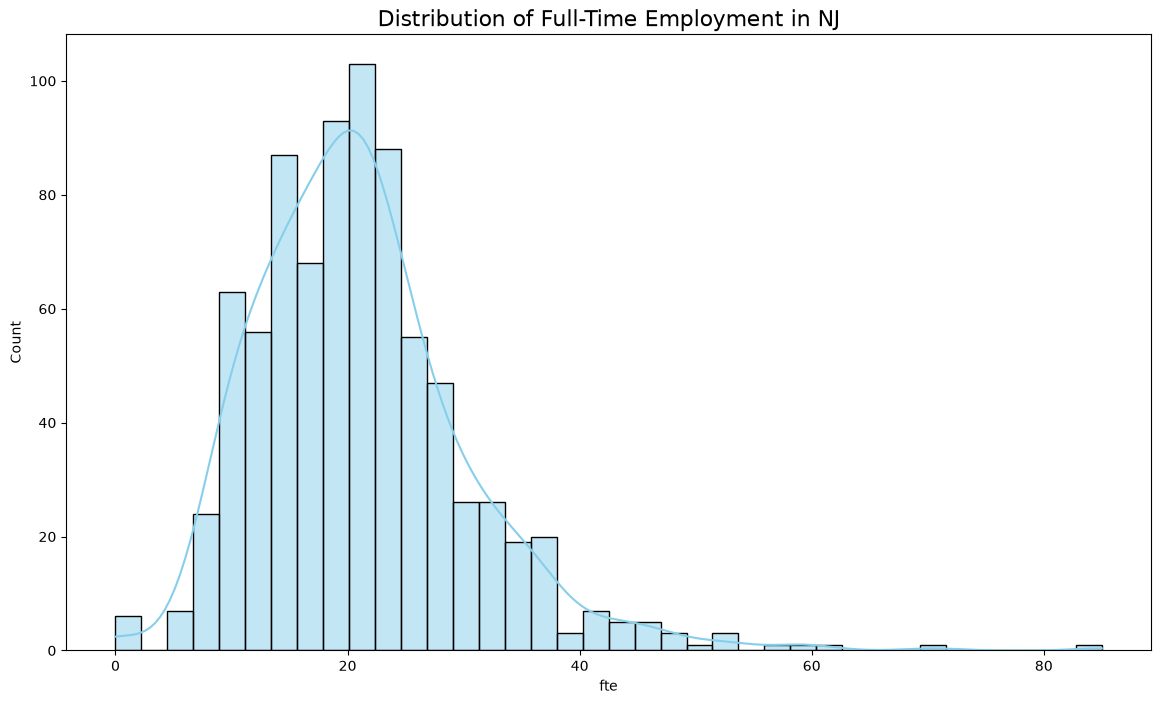

In [13]:
# Distribution of Full-Time Employment in New Jersey
plt.figure(figsize=(14, 8))
sns.histplot(data=data, x='fte', kde=True, color='skyblue')
plt.title('Distribution of Full-Time Employment in NJ', fontsize=16)
plt.show()

/Users/emmanueldanielchonza/Documents/Documents - Emmanuel’s MacBook Pro/Education/Projects/Econometrics-and-Research-Techniques/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


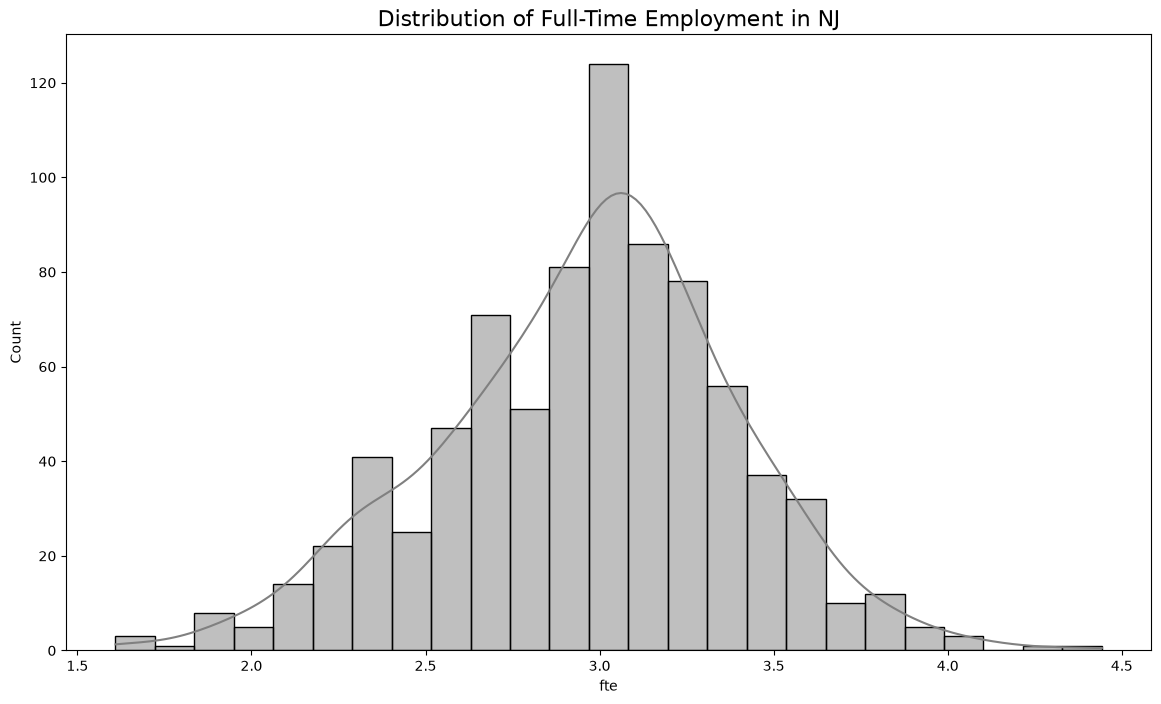

In [14]:
# Distribution of Full-Time Employment in New Jersey
plt.figure(figsize=(14, 8))
sns.histplot(data=data, x=np.log(data['fte']), kde=True, color='grey')
plt.title('Distribution of Full-Time Employment in NJ', fontsize=16)
plt.show()

## Build Model1

In [15]:
# Create a data copy
df = data.copy()
df.head()

,NJ,POST_APRIL92,NJ_POST_APRIL92,fte,bk,kfc,roys,wendys,co_owned,centralj,southj,pa1,pa2,demp
0,1,0,0,15.00,1,0,0,0,0,1,0,0,0,12.00
1,1,0,0,15.00,1,0,0,0,0,1,0,0,0,6.50
2,1,0,0,24.00,0,0,1,0,0,1,0,0,0,-1.00
3,1,0,0,19.25,0,0,1,0,1,0,0,0,0,2.25
4,1,0,0,21.50,1,0,0,0,0,0,0,0,0,13.00


In [16]:
# Create a data copy
df = data.copy()
TARGET = 'fte'
X = df.iloc[:,:3]
y = df[TARGET]

In [17]:
import statsmodels.api as sm

# Add constants
X1 = sm.add_constant(X)
X1.head()

,const,NJ,POST_APRIL92,NJ_POST_APRIL92
0,1.0,1,0,0
1,1.0,1,0,0
2,1.0,1,0,0
3,1.0,1,0,0
4,1.0,1,0,0


In [18]:
# Fit the linear model
model1 = sm.OLS(y, X1).fit()

# Print model summary with interpretable variable names
print(
    model1.summary(
        yname="Full-time Employee (fte)",
        xname=[
            "Intercept",
            "New Jersey",
            "After April 1992",
            "New Jersey × After April 1992"
        ]
    )
)

                               OLS Regression Results                               
Dep. Variable:     Full-time Employee (fte)   R-squared:                       0.007
Model:                                  OLS   Adj. R-squared:                  0.004
Method:                       Least Squares   F-statistic:                     1.974
Date:                      Wed, 15 Jul 2026   Prob (F-statistic):              0.116
Time:                              20:35:30   Log-Likelihood:                -2986.2
No. Observations:                       820   AIC:                             5980.
Df Residuals:                           816   BIC:                             5999.
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

## 6.0 Interpretation of the Baseline Difference-in-Differences Model
The baseline model estimates the relationship between full-time equivalent employment and three core Difference-in-Differences variables: `NJ`, `POST_APRIL92`, and `NJ_POST_APRIL92`.

The estimated coefficient on `NJ` is negative, indicating that before the policy change, New Jersey restaurants had lower average full-time equivalent employment than Pennsylvania restaurants.

The estimated coefficient on `POST_APRIL92` is also negative, suggesting that Pennsylvania restaurants experienced a decline in employment after April 1992. However, this post-period effect is not statistically significant in the baseline model.

The key coefficient is the interaction term `NJ_POST_APRIL92`. In the baseline model, this coefficient is positive at approximately **2.68**. This means that after the minimum wage increase, New Jersey restaurants had about **2.68 more full-time equivalent employees** relative to the employment change observed in Pennsylvania.

Although the estimate is only weakly statistically significant depending on the model specification, its positive sign is important. It suggests that the New Jersey minimum wage increase was not associated with employment losses relative to Pennsylvania.

## Create Model2 by Adding up Control Features

In [19]:
# Get dataset
X_features = df.drop('fte', axis=1)
X2 = X_features.iloc[:,:7]
X2

,NJ,POST_APRIL92,NJ_POST_APRIL92,bk,kfc,roys,wendys
0,1,0,0,1,0,0,0
1,1,0,0,1,0,0,0
2,1,0,0,0,0,1,0
3,1,0,0,0,0,1,0
4,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...
815,0,1,0,0,0,1,0
816,0,1,0,0,0,1,0
817,0,1,0,0,0,1,0
818,0,1,0,1,0,0,0


In [20]:
# Add Constants
X2 = sm.add_constant(X2)

# Create and fit data to model2
model2 = sm.OLS(y, X2).fit()

# Get the model results
print(model2.summary(
    yname = "FTE",
    xname = ['Intercept', 'New Jersey ', 'POST APRIL 1992', 'NJ POST APRIL 1992', 
             'Burger King', 'KFC', 'ROYS','WENDYS'],
))

                            OLS Regression Results                            
Dep. Variable:                    FTE   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     31.95
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           1.30e-34
Time:                        20:38:22   Log-Likelihood:                -2902.4
No. Observations:                 820   AIC:                             5819.
Df Residuals:                     813   BIC:                             5852.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             17.6685      0

In [21]:
# Get dataset for model 3
X_features1 = df.drop(['fte', 'roys'], axis=1)
X3 = X_features1.iloc[:,:11]
X3.head()

,NJ,POST_APRIL92,NJ_POST_APRIL92,bk,kfc,wendys,co_owned,centralj,southj,pa1,pa2
0,1,0,0,1,0,0,0,1,0,0,0
1,1,0,0,1,0,0,0,1,0,0,0
2,1,0,0,0,0,0,0,1,0,0,0
3,1,0,0,0,0,0,1,0,0,0,0
4,1,0,0,1,0,0,0,0,0,0,0


## Build Model 3 with additional Control Features Included

In [22]:
# Add Constants
X3 = sm.add_constant(X3)

# Create and fit data to model2
model3 = sm.OLS(y, X3).fit()

# Get the model results
print(model3.summary(
    yname = 'FTE',
    xname = ['Intercept', 'New Jersey', 'POST APRIL 1992', 'New Jersey POST APRIL 1992', 'Burger King', 
             'KFC', 'WENDYS', 'CO-OWNED', 'Central Jersey', 'South Jersey', 'PA Philly Suburb', 'PA Other Area']
))

                            OLS Regression Results                            
Dep. Variable:                    FTE   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     22.43
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           2.66e-37
Time:                        20:40:46   Log-Likelihood:                -2888.8
No. Observations:                 820   AIC:                             5800.
Df Residuals:                     809   BIC:                             5851.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

## Build Model 4 After Excluding centralj region

In [23]:
X_features2 = df[['NJ', 'POST_APRIL92', 'NJ_POST_APRIL92', 'bk', 'kfc', 'roys',
       'wendys', 'co_owned', 'southj']]

# Add Constants
X4 = sm.add_constant(X_features2)

# Create and fit data to model2
model4 = sm.OLS(y, X4).fit()

# Get the model results
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     28.04
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           1.18e-38
Time:                        20:41:46   Log-Likelihood:                -2889.1
No. Observations:                 820   AIC:                             5796.
Df Residuals:                     811   BIC:                             5838.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              17.9563      0.781     

## Models' Results

In [24]:
# Extract model coefficients
intercept, nj_coef, post_april1992_coef, nj_post_april1992_coef = model1.params
model1.params

const              23.272823
NJ                 -2.815678
POST_APRIL92       -2.110759
NJ_POST_APRIL92     2.681010
dtype: float64

### Calculate FTE for each 

In [25]:
# Create the plot variables
pre_pa = intercept
post_pa = intercept + post_april1992_coef
pre_nj = intercept + nj_coef
post_nj = intercept + nj_coef + post_april1992_coef + nj_post_april1992_coef
counterfactual = intercept + nj_coef + post_april1992_coef

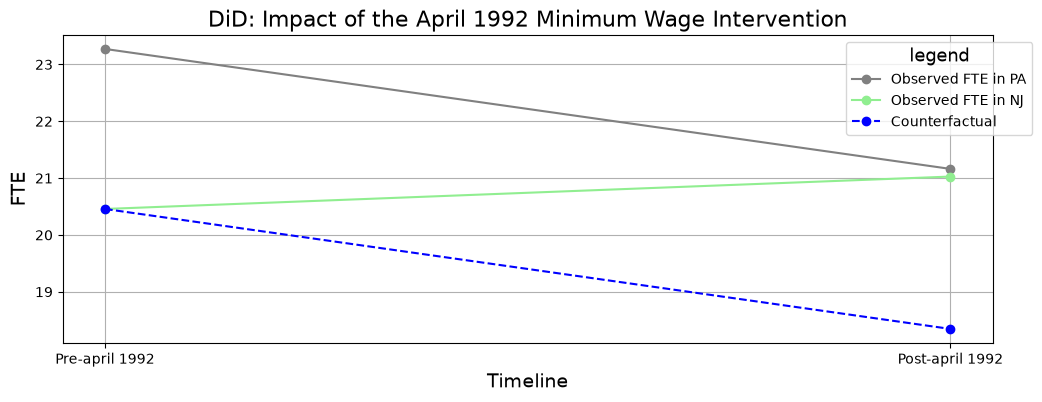

In [26]:
# Plot
plt.figure(figsize=(12, 4))
time= ['Pre-april 1992', 'Post-april 1992'] 
# Create the plot
plt.plot(time,
[pre_pa, post_pa],
marker='o',
linestyle='-',
color='grey',
label='Observed FTE in PA'
)

plt.plot(time,
[pre_nj, post_nj],
marker='o',
linestyle='-',
color='lightgreen',
label='Observed FTE in NJ'
)

plt.plot(time,
[pre_nj, counterfactual],
marker='o',
linestyle='--',
color='blue',
label='Counterfactual'
)

# Add figure Annotations
plt.title("DiD: Impact of the April 1992 Minimum Wage Intervention", fontsize=16)
plt.xlabel("Timeline", fontsize=14)
plt.ylabel('FTE', fontsize=14)
plt.legend(
    loc='upper right',
    title='legend',
    fontsize=10,
    frameon=True,
    title_fontsize=13,
    bbox_to_anchor=(1.05, 1)
)
plt.grid(True)
plt.show()

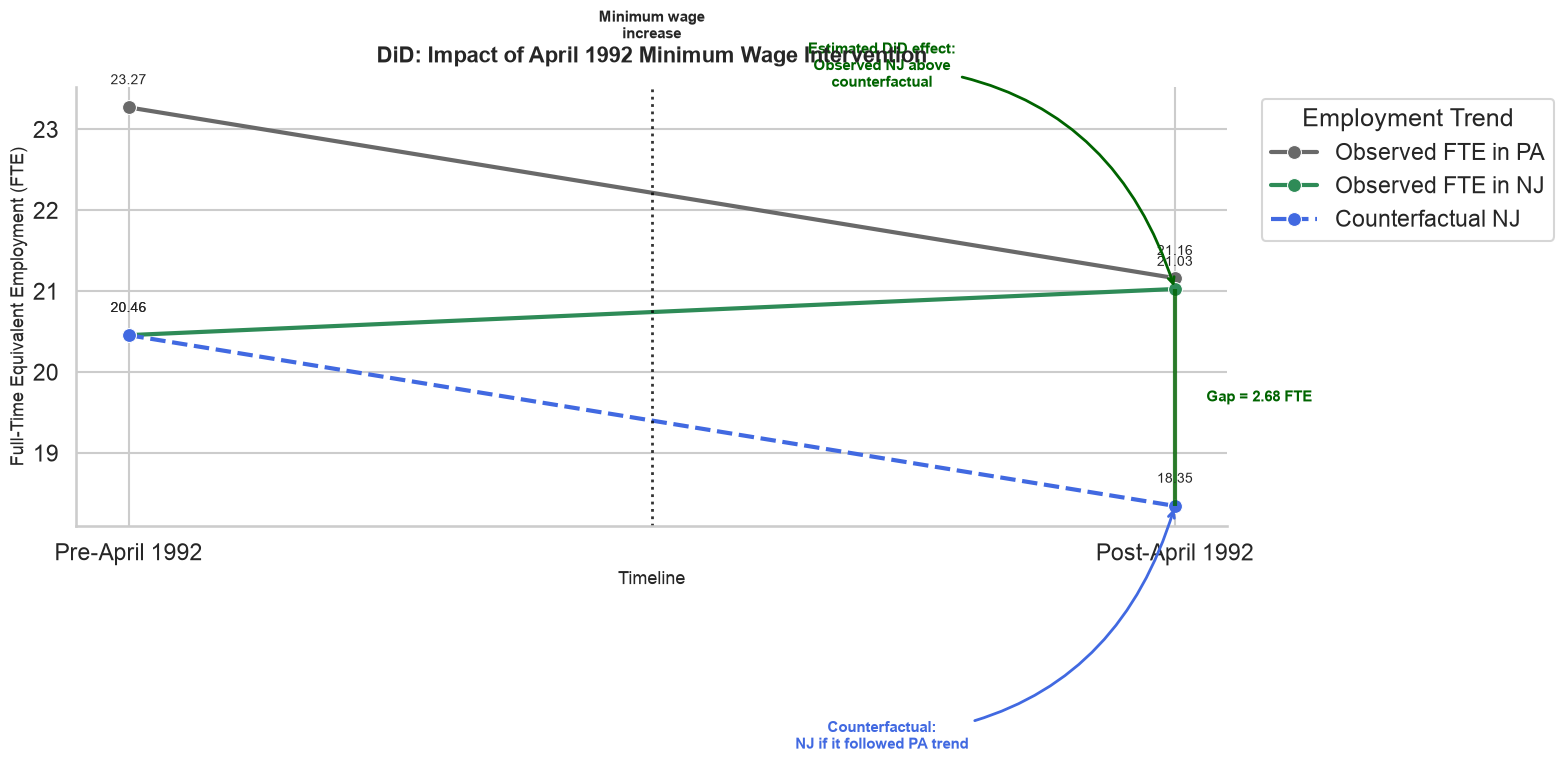

In [27]:
# Enhanced DiD Visualization with Seaborn Styling
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set Seaborn theme for a cleaner visual style
sns.set_theme(style="whitegrid", context="talk")

# Create plotting dataframe
did_plot_df = pd.DataFrame({
    "Timeline": [
        "Pre-April 1992", "Post-April 1992",
        "Pre-April 1992", "Post-April 1992",
        "Pre-April 1992", "Post-April 1992"
    ],
    "FTE": [
        pre_pa, post_pa,
        pre_nj, post_nj,
        pre_nj, counterfactual
    ],
    "Series": [
        "Observed FTE in PA", "Observed FTE in PA",
        "Observed FTE in NJ", "Observed FTE in NJ",
        "Counterfactual NJ", "Counterfactual NJ"
    ]
})

# Define colors manually for policy-friendly readability
palette = {
    "Observed FTE in PA": "dimgray",
    "Observed FTE in NJ": "seagreen",
    "Counterfactual NJ": "royalblue"
}

# Create figure
plt.figure(figsize=(16, 10))

# Draw observed PA and NJ lines using seaborn
sns.lineplot(
    data=did_plot_df[did_plot_df["Series"] != "Counterfactual NJ"],
    x="Timeline",
    y="FTE",
    hue="Series",
    marker="o",
    linewidth=3,
    markersize=10,
    palette=palette
)

# Draw counterfactual line separately to control dashed style
counterfactual_df = did_plot_df[did_plot_df["Series"] == "Counterfactual NJ"]

sns.lineplot(
    data=counterfactual_df,
    x="Timeline",
    y="FTE",
    marker="o",
    linewidth=3,
    markersize=10,
    linestyle="--",
    color=palette["Counterfactual NJ"],
    label="Counterfactual NJ"
)

# Add value labels to all points
for _, row in did_plot_df.iterrows():
    plt.text(
        x=row["Timeline"],
        y=row["FTE"] + 0.25,
        s=f"{row['FTE']:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Add vertical policy intervention marker between pre and post periods
plt.axvline(
    x=0.5,
    color="black",
    linestyle=":",
    linewidth=2,
    alpha=0.8
)

plt.text(
    x=0.5,
    y=max(did_plot_df["FTE"]) + 0.8,
    s="Minimum wage\nincrease",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

# Add curved arrow showing the DiD treatment effect gap
plt.annotate(
    text="Estimated DiD effect:\nObserved NJ above\ncounterfactual",
    xy=("Post-April 1992", post_nj),
    xytext=(0.72, post_nj + 2.5),
    textcoords="data",
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.35",
        linewidth=2,
        color="darkgreen"
    ),
    fontsize=11,
    fontweight="bold",
    color="darkgreen",
    ha="center"
)

# Add another arrow pointing to counterfactual line
plt.annotate(
    text="Counterfactual:\nNJ if it followed PA trend",
    xy=("Post-April 1992", counterfactual),
    xytext=(0.72, counterfactual - 3.0),
    textcoords="data",
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=0.35",
        linewidth=2,
        color="royalblue"
    ),
    fontsize=11,
    fontweight="bold",
    color="royalblue",
    ha="center"
)

# Highlight the vertical gap between observed NJ and counterfactual NJ
plt.vlines(
    x=1,
    ymin=counterfactual,
    ymax=post_nj,
    colors="darkgreen",
    linestyles="-",
    linewidth=3,
    alpha=0.8
)

plt.text(
    x=1.03,
    y=(post_nj + counterfactual) / 2,
    s=f"Gap = {post_nj - counterfactual:.2f} FTE",
    fontsize=11,
    fontweight="bold",
    color="darkgreen",
    va="center"
)

# Add title and labels
plt.title(
    "DiD: Impact of April 1992 Minimum Wage Intervention",
    fontsize=16,
    fontweight="bold",
    pad=18
)

plt.xlabel("Timeline", fontsize=13)
plt.ylabel("Full-Time Equivalent Employment (FTE)", fontsize=13)

# Improve legend
plt.legend(
    title="Employment Trend",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True
)

# Remove unnecessary borders
sns.despine()

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

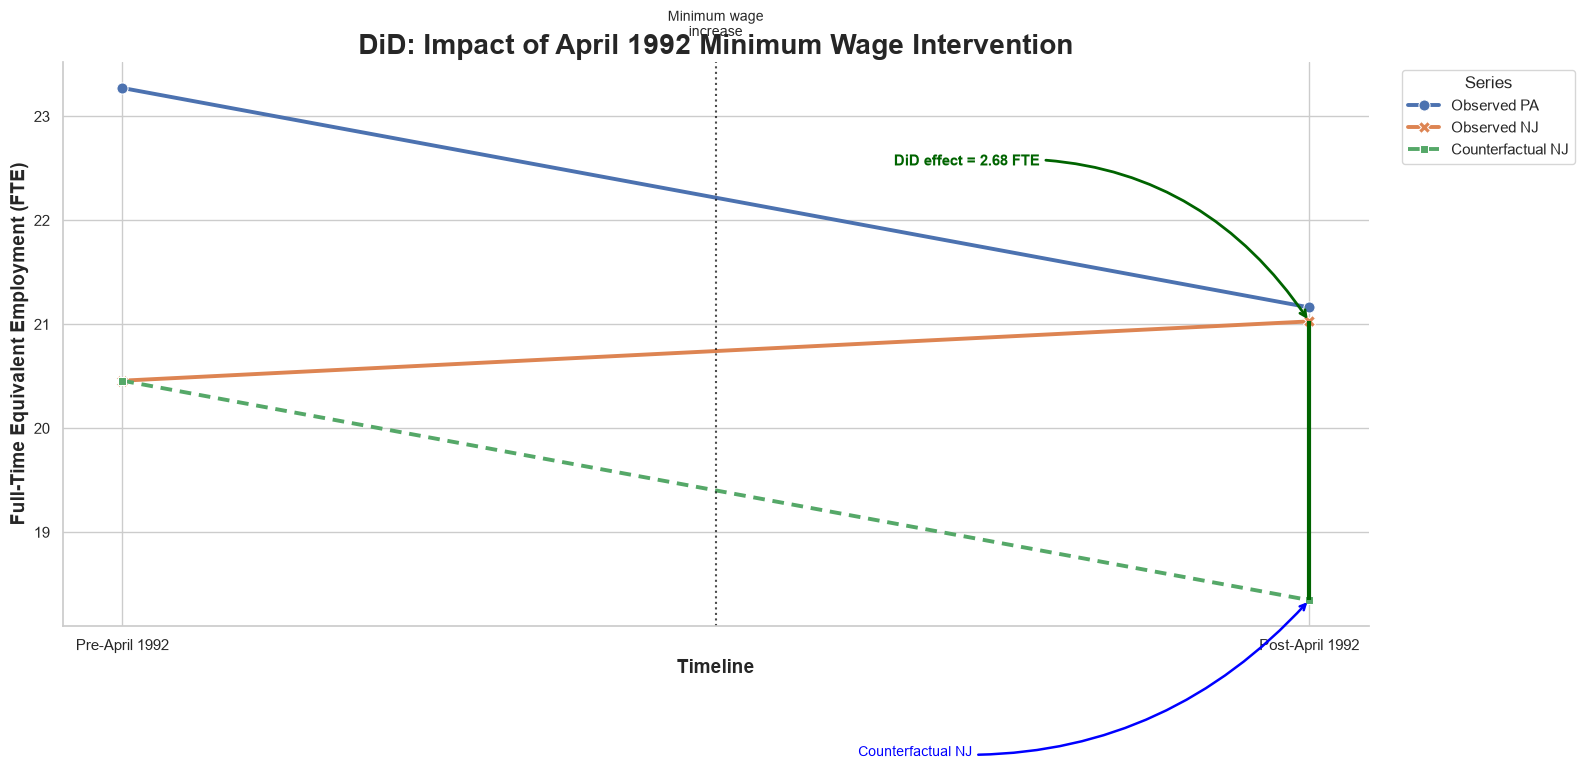

In [29]:
# Efficient Seaborn-enhanced DiD plot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Prepare plot data
plot_df = pd.DataFrame({
    "Period": ["Pre-April 1992", "Post-April 1992"] * 3,
    "FTE": [pre_pa, post_pa, pre_nj, post_nj, pre_nj, counterfactual],
    "Series": ["Observed PA"] * 2 + ["Observed NJ"] * 2 + ["Counterfactual NJ"] * 2
})

# Plot observed PA and NJ
plt.figure(figsize=(16, 8))

sns.lineplot(
    data=plot_df,
    x="Period",
    y="FTE",
    hue="Series",
    style="Series",
    markers=True,
    dashes={
        "Observed PA": "",
        "Observed NJ": "",
        "Counterfactual NJ": (3, 2)
    },
    linewidth=2.8,
    markersize=8
)

# Policy intervention marker
plt.axvline(0.5, color="black", linestyle=":", alpha=0.7)
plt.text(0.5, plot_df["FTE"].max() + 0.5, "Minimum wage\nincrease", ha="center", fontsize=10)

# Treatment effect gap
plt.vlines(
    x=1,
    ymin=counterfactual,
    ymax=post_nj,
    color="darkgreen",
    linewidth=3
)

# Curved arrow and label
plt.annotate(
    f"DiD effect = {post_nj - counterfactual:.2f} FTE",
    xy=(1, post_nj),
    xytext=(0.65, post_nj + 1.5),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=-0.3",
        color="darkgreen",
        lw=2
    ),
    fontsize=11,
    color="darkgreen",
    fontweight="bold"
)

# Counterfactual label
plt.annotate(
    "Counterfactual NJ",
    xy=(1, counterfactual),
    xytext=(0.62, counterfactual - 1.5),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=0.25",
        color="blue",
        lw=1.8
    ),
    fontsize=10,
    color="blue"
)

# Titles and labels
plt.title("DiD: Impact of April 1992 Minimum Wage Intervention", fontsize=20, weight="bold")
plt.xlabel("Timeline", fontsize=14, weight="bold")
plt.ylabel("Full-Time Equivalent Employment (FTE)", fontsize=14, weight="bold")
plt.legend(title="Series", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()

## Chart Insight Summary

The last chart provides a clear visual summary of the Difference-in-Differences result.

- Pennsylvania employment declined after April 1992.
- New Jersey employment did not decline in the same way.
- The counterfactual line shows that New Jersey employment would have been lower if it had followed Pennsylvania's post-period employment trend.
- The observed New Jersey post-policy employment level is above the counterfactual line.
- The vertical gap between observed New Jersey employment and counterfactual New Jersey employment represents the estimated policy effect.
- This gap is positive, consistent with the positive Difference-in-Differences coefficient.

The chart therefore supports the main conclusion:

**The April 1992 New Jersey minimum wage increase did not reduce employment relative to Pennsylvania.**

## 7.0 Last Chart Interpretation: Difference-in-Differences Employment Trend

* The final chart visualizes the Difference-in-Differences logic by comparing observed employment trends in Pennsylvania and New Jersey before and after the April 1992 minimum wage intervention.
* The grey line represents observed full-time equivalent employment in Pennsylvania. Pennsylvania is the comparison group because it was not directly affected by the New Jersey minimum wage increase.
* The light green line represents observed full-time equivalent employment in New Jersey. This is the treatment group because New Jersey restaurants were exposed to the minimum wage increase.
* The blue dashed line represents the counterfactual trend for New Jersey. This line estimates what New Jersey employment would have looked like after April 1992 if New Jersey had followed the same post-period employment change observed in Pennsylvania.
* The chart shows that Pennsylvania employment declined after April 1992. If New Jersey had followed the same trend, its employment would also have declined along the counterfactual path. However, the observed New Jersey employment line is above the counterfactual line after the policy intervention.
* This gap between the observed New Jersey post-policy employment and the counterfactual New Jersey employment is the visual representation of the Difference-in-Differences estimate.

## 8.0 Policy Interpretation of the Last Chart

The chart provides an intuitive policy interpretation of the regression results.

* The main policy concern is whether increasing the minimum wage caused employers to reduce employment. If the minimum wage increase had reduced employment, we would expect the observed New Jersey employment line to fall below the counterfactual trend after April 1992.

* However, the chart shows the opposite pattern. New Jersey's observed post-policy employment is above its counterfactual employment path. This suggests that New Jersey restaurants did not reduce employment relative to Pennsylvania after the minimum wage increase.

* The estimated Difference-in-Differences effect is positive, indicating that New Jersey restaurants experienced a relative employment gain compared with what would have been expected if they had followed Pennsylvania's employment trend.

* Therefore, the visual evidence supports the conclusion that the April 1992 New Jersey minimum wage increase was not associated with a reduction in fast-food employment.

## 9.0 Economic Interpretation

From an economic perspective, the results challenge the simple prediction that a minimum wage increase necessarily reduces employment. The positive Difference-in-Differences estimate suggests that employment in New Jersey did not fall relative to Pennsylvania after the minimum wage increase.

There are several possible explanations for this outcome.

  * First, fast-food labor markets may not behave like perfectly competitive labor markets. If employers have some wage-setting power, a higher minimum wage may increase wages without necessarily reducing employment.

  * Second, higher wages may reduce worker turnover, improve worker effort, or increase labor supply, allowing firms to maintain employment levels.

  * Third, firms may adjust to higher labor costs through other margins, such as price changes, productivity improvements, reduced vacancies, or operational adjustments, rather than by reducing employment.

  * Fourth, the observed employment outcome may reflect broader local demand conditions that supported continued hiring or stable staffing in New Jersey restaurants.

Overall, the evidence suggests that the employment effect of minimum wage policy is an empirical question and should be evaluated using real-world data rather than assumed purely from theory.

## 10.0 Final Project Conclusion

The Difference-in-Differences analysis finds no evidence that the April 1992 New Jersey minimum wage increase reduced employment in the fast-food sector relative to Pennsylvania.

The key treatment effect, represented by the interaction term `NJ_POST_APRIL92`, is positive across the estimated models. In the baseline model, the estimated effect is approximately **2.68 additional full-time equivalent employees** relative to the Pennsylvania comparison trend.

The final chart reinforces this finding visually. The observed New Jersey post-policy employment trend lies above the counterfactual trend, suggesting that employment in New Jersey performed better than would have been expected if it had followed the Pennsylvania post-period pattern.

The preferred interpretation is that the New Jersey minimum wage increase did not lead to employment losses in the fast-food restaurants included in this analysis. If anything, the point estimate suggests a modest relative employment increase, although the statistical evidence should be interpreted cautiously where significance is weak.

From a policy perspective, the results support the view that minimum wage increases do not automatically result in job losses. The employment impact depends on labor market conditions, employer behavior, business adjustment channels, and local economic context.

## 11.0 Recommended Policy Message
The findings suggest that policymakers should avoid assuming that minimum wage increases necessarily reduce employment. In this case, the New Jersey minimum wage increase was not associated with a decline in fast-food employment relative to Pennsylvania.

However, policy decisions should still be evidence-based and context-specific. Minimum wage increases should be accompanied by monitoring of employment, business costs, prices, worker earnings, firm survival, and labor market outcomes across different sectors.

The Difference-in-Differences evidence from this project suggests that moderate minimum wage increases can be implemented without necessarily harming employment, especially where firms have adjustment mechanisms beyond reducing labor.

A balanced policy recommendation is therefore:

**Minimum wage policy should be evaluated not only by its theoretical employment risk, but also by its observed impacts on employment, wages, worker welfare, and firm adjustment behavior.**

## 12.0 Limitations and Cautions
Although the results are informative, several limitations should be considered.

First, the Difference-in-Differences method relies on the parallel trends assumption. This means that in the absence of the minimum wage increase, New Jersey and Pennsylvania restaurants would have followed similar employment trends. If this assumption does not hold, the estimated treatment effect may be biased.

Second, the analysis is based on the fast-food sector and may not generalize to all industries. Other sectors may respond differently to minimum wage changes depending on labor intensity, profit margins, automation potential, and demand conditions.

Third, the estimated treatment effect captures the average short-term impact around the policy period. It may not fully capture longer-term employment adjustments.

Fourth, unobserved factors such as local demand shocks, management practices, changes in prices, labor turnover, or regional economic conditions may also affect employment.

Fifth, statistical significance is relatively weak in some specifications. Therefore, the results should be interpreted as evidence against employment losses rather than definitive proof of a large positive employment effect.

Despite these limitations, the stability and positive direction of the Difference-in-Differences estimate provide useful evidence that the minimum wage increase did not reduce employment in the analyzed sample.